***Heart Disease Prediction***

**OBJECTIVE**

The goal of this project is to build a machine learning model
that predicts whether a person is at risk of heart disease
based on medical attributes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

In [4]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci.csv


In [6]:
df = pd.read_csv("heart_disease_uci.csv")

# Display first 5 rows
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [7]:
# Shape
print("Dataset Shape:", df.shape)

# Column names
print("Columns:\n", df.columns)

# Info
df.info()

Dataset Shape: (920, 16)
Columns:
 Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-nu

In [8]:
# Check missing values
print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [15]:


df.drop(['ca', 'thal', 'slope'], axis=1, inplace=True)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].mean()
)
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

/tmp/ipykernel_1778/1165656787.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [16]:
#handle missing values
print(df.isnull().sum())

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64


In [19]:
df = pd.get_dummies(df, drop_first=True)

In [20]:
# Features
X = df.drop('num', axis=1)

# Binary target
y = (df['num'] > 0).astype(int)

In [21]:
#splitting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
#logistic regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [23]:
#prediction
y_pred = model.predict(X_test)

In [24]:
#accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8152173913043478


[[60 15]
 [19 90]]


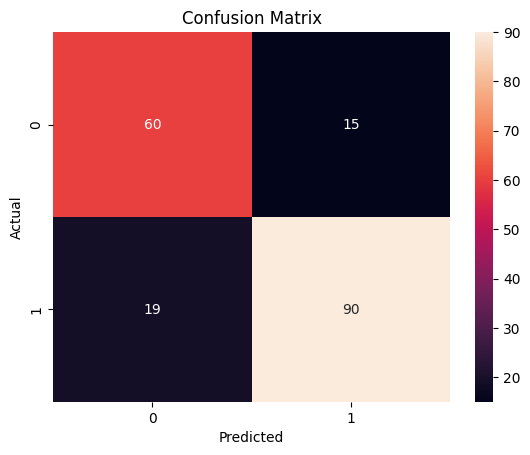

In [25]:
#confusin matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

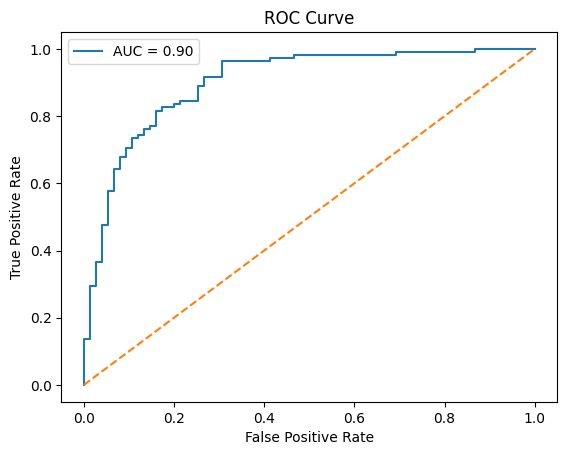

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilities
y_prob = model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure()

plt.plot(fpr, tpr, label='AUC = %.2f' % auc)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [27]:
#feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                     Feature  Importance
9        dataset_Switzerland    2.409764
7                   sex_Male    1.494220
5                      exang    0.984085
6                    oldpeak    0.670149
3                        fbs    0.390734
10     dataset_VA Long Beach    0.132101
15  restecg_st-t abnormality    0.129828
0                        age    0.017690
1                   trestbps    0.001505
2                       chol    0.000862
14            restecg_normal    0.000057
4                     thalch   -0.011993
8            dataset_Hungary   -0.185897
12            cp_non-anginal   -1.143915
13         cp_typical angina   -1.208668
11        cp_atypical angina   -1.694367


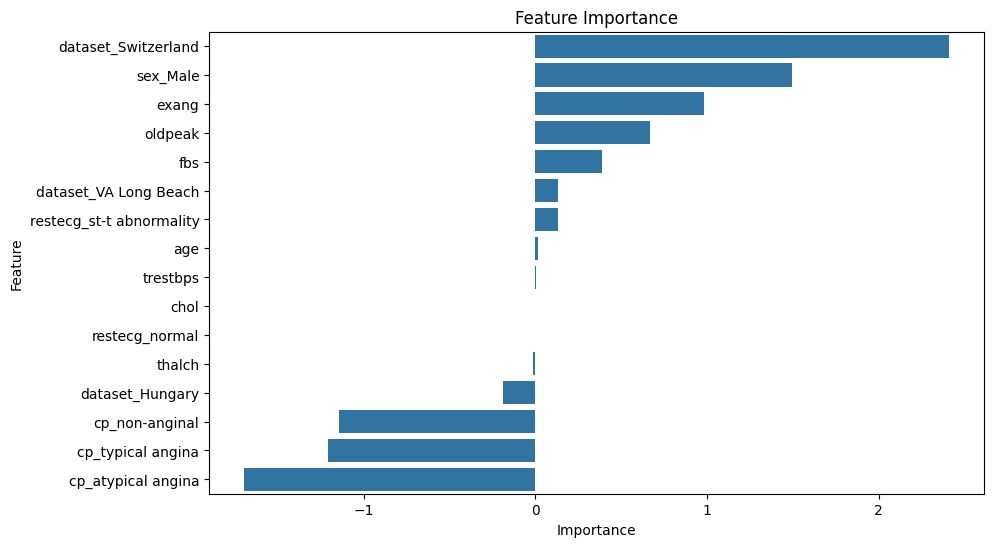

In [29]:
#plotting visualization
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

## Results and Insights

- Logistic Regression achieved good accuracy.
- ROC curve indicates strong classification performance.

- The model can help identify heart disease risk early.

The dataset was clean and suitable for classification.

## Conclusion

In this project, we built a Heart Disease Prediction model
using Logistic Regression.

We performed:
- Data cleaning
- EDA
- Model training
- Accuracy evaluation
- ROC analysis
- Feature importance analysis

This project demonstrates how machine learning
can assist in medical diagnosis.